**Sentimen Analisis Review Aplikasi Duolingo di Playstore**

Pada proyek ini, akan dilakukan analisis sentimen terhadap ulasan dan pendapat pengguna terkait aplikasi "Duolingo" di Play Store. Analisis sentimen akan membantu kita untuk memahami bagaimana pengguna merasakan dan mengungkapkan pandangan mereka terhadap aplikasi ini.

Dengan menggunakan berbagai teknik pemrosesan teks dan algoritma machine learning, kita akan mencoba mengidentifikasi apakah ulasan pengguna terhadap aplikasi "Duolingo" cenderung positif, negatif, atau netral. Hasil analisis sentimen ini dapat memberikan wawasan berharga kepada pengembang aplikasi untuk meningkatkan pengalaman pengguna.


# **Import Library**

In [ ]:
import csv
import requests
from io import StringIO
import pandas as pd  # Pandas untuk manipulasi dan analisis data
import numpy as np  # NumPy untuk komputasi numerik
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca

from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

!pip install wordcloud
from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score

In [123]:
import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stop words) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Loading Dataset

In [124]:
# Open Dataset
app_reviews_df = pd.read_csv('Dataset_Scraping.csv')

In [125]:
# Menampilkan lima baris pertama dari DataFrame app_reviews_df
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,4041b377-b5dd-4f58-8610-80f0502e5b8f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Aplikasi yang menarik, kita bisa berbagi cerita dan sharing banyak hal denga pengguna lainnya. Ada fitur editing yang mudah diaplikasikan, membantu sekali untuk kreator pemula. Sayangnya, postingan yang muncul seringkali postingan lama, bukan yang terbaru. Semoga segera update agar postingan baru muncul di beranda paling atas.",5,1111,7.9.5,2025-01-30 12:22:40,NaN,NaN,7.9.5
1,3591ad33-9acb-45ef-90de-9d1a400d80ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"kasih 4dlu klo bagus kaya tiktok dan waveful nnti tak kasih bintang5 ,rada susah buat pertemanan sama fiturnya blm paham klo pemula ,klo di waveful kan simple pemula saja gampang buat nyari followers ,udah gitu dollar nya cepat monet",4,12,8.4.0,2025-03-30 11:36:49,NaN,NaN,8.4.0
2,132838cf-0fda-41f6-bb99-d5acb53f9c18,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Balikin akun aku yg lama. Terserah kalian mau join sm tiktok atau gak, tp please gausah egois begini aplikasi yg tadinya mempermudah jd mempersulit. Mana maksa bgt login pake tiktok, akun yg tadinya ada followers, konten, dll jd hilang gt aja. Mau pulihkan akun juga ga bisa! Makin benci aja sm tiktok kesannya semua harus tertuju sm tiktok! Sampe aplikasi lemon8 juga dikuasai!!",1,85,7.9.5,2025-02-10 13:17:23,NaN,NaN,7.9.5
3,9b500c79-f584-4ffd-aa84-ddd953f30bf1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Sebelumnya suka dengan aplikasi ini, banyak info dan tips menarik. Tapi gak suka bgt setelah pembaharuan dan dipaksa login dengan tiktok. Tolong kembalikan fitur login dengan email, karna tidak semua org pakai tiktok",1,75,7.9.5,2025-01-29 18:03:14,NaN,NaN,7.9.5
4,3b102fe2-e915-48e5-b15f-393aa7cfd580,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Kecewa ada kebijakan baru login harus pakai tiktok, sedangkan aku ga instal tiktok, gakmuat memori, juga gasuka tiktok tp pengen banget masuk lemon8 kayak dulu karna suka sama artikel"" Dan hack. Dan gkada jalan buat bisa masuk,",4,36,8.1.5,2025-03-03 21:09:00,NaN,NaN,8.1.5


In [126]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15380 entries, 0 to 15379
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              15380 non-null  object
 1   userName              15380 non-null  object
 2   userImage             15380 non-null  object
 3   content               15380 non-null  object
 4   score                 15380 non-null  int64 
 5   thumbsUpCount         15380 non-null  int64 
 6   reviewCreatedVersion  13217 non-null  object
 7   at                    15380 non-null  object
 8   replyContent          201 non-null    object
 9   repliedAt             201 non-null    object
 10  appVersion            13217 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.3+ MB


**Insight:** Dari informasi di atas, terlihat bahwa kolom replyContent dan repliedAt hampir semuanya NA (data hilang) sehingga tidak cukup digunakan untuk mencari informasi. Penanganan data hilang ini adalah dengan menghapus kedua kolom sekaligus.

In [127]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.drop(['replyContent', 'repliedAt'], axis=1)

In [128]:
# Menampilkan informasi tentang DataFrame clean_df setelah membersihkan nilai yang hilang (NaN)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15380 entries, 0 to 15379
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              15380 non-null  object
 1   userName              15380 non-null  object
 2   userImage             15380 non-null  object
 3   content               15380 non-null  object
 4   score                 15380 non-null  int64 
 5   thumbsUpCount         15380 non-null  int64 
 6   reviewCreatedVersion  13217 non-null  object
 7   at                    15380 non-null  object
 8   appVersion            13217 non-null  object
dtypes: int64(2), object(7)
memory usage: 1.1+ MB


In [129]:
clean_df.duplicated().sum()

np.int64(0)

**Insight:** Data tidak memiliki duplikasi.

## Preprocessing

Berikut adalah beberapa fungsi yang digunakan untuk membersihkan dan memproses teks. Inilah penjelasan singkat tentang masing-masing fungsi:

1. `cleaningText(text)`: Fungsi ini digunakan untuk membersihkan teks dengan beberapa langkah, seperti menghapus mention, hashtag, RT (retweet), tautan (link), angka, dan tanda baca. Selain itu, itu juga menggantikan karakter newline dengan spasi dan menghilangkan spasi ekstra di awal dan akhir teks.

2. `casefoldingText(text)`: Fungsi ini mengonversi semua karakter dalam teks menjadi huruf kecil (lowercase), sehingga teks menjadi lebih seragam.

3. `tokenizingText(text)`: Fungsi ini digunakan untuk membagi teks menjadi daftar kata atau token. Ini berguna untuk mengurai teks menjadi komponen-komponen dasar.

4. `filteringText(text)`: Fungsi ini digunakan untuk menghapus kata-kata berhenti (stopwords) dalam teks. Anda telah memperbarui daftar kata-kata berhenti dengan beberapa kata tambahan.

5. `stemmingText(text)`: Fungsi ini menerapkan stemming pada teks, yaitu mengurangi kata-kata menjadi bentuk dasarnya. Anda menggunakan pustaka Sastrawi untuk melakukan stemming dalam bahasa Indonesia.

6. `toSentence(list_words)`: Fungsi ini digunakan untuk menggabungkan daftar kata-kata menjadi sebuah kalimat.

Fungsi-fungsi ini digunakan untuk membersihkan, memproses, dan mempersiapkan teks sebelum melakukan analisis sentimen.

In [130]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # remove hashtag
    text = re.sub(r'RT[\s]', '', text) # remove RT
    text = re.sub(r"http\S+", '', text) # remove link
    text = re.sub(r'[0-9]+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove numbers
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\[\w+]', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\b\w+(?:com|org)\b', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    text = text.replace('\n', ' ') # replace new line into space
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuations
    text = text.strip(' ') # remove characters space from both left and right text
    return text

def casefoldingText(text): # Converting all the characters in a text into lower case
    text = text.lower()
    return text

def tokenizingText(text): # Tokenizing or splitting a string, text into a list of tokens
    text = word_tokenize(text)
    return text

def filteringText(text): # Remove stopwors in a text
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Reducing a word to its word stem that affixes to suffixes and prefixes or to the roots of words
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

    return stemmed_text
def toSentence(list_words): # Convert list of words into sentence
    sentence = ' '.join(word for word in list_words)
    return sentence

In [131]:
# kamus 1
sl1 = {"@": "di", "abis": "habis", "ad": "ada", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}

# kamus2
sl2 = pd.read_csv("https://raw.githubusercontent.com/haryoa/indo-collex/main/dict/inforformal-formal-Indonesian-dictionary.tsv", sep="\t")
sl2.set_index("informal", drop=True, inplace=True)
sl2 = sl2.to_dict()["formal"]
sl2

# kamus 3
sl3 = pd.read_csv("https://raw.githubusercontent.com/ramaprakoso/analisis-sentimen/master/kamus/kbba.txt", sep="\t", header=None)
sl3.set_index(0, drop=True, inplace=True)
sl3 = sl3.to_dict()[1]

# Gabungkan semua kamus slang words
slangwords = {**sl1, **sl2, **sl3}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

Kamus slang atau daftar kata-kata slang yang Anda berikan adalah kumpulan kata-kata slang bahasa Indonesia beserta terjemahan atau artinya dalam bahasa formal. Fungsi dari kamus slang seperti ini adalah:

1. **Mengartikan Slang:** Kamus slang membantu orang yang mungkin tidak familiar dengan bahasa slang atau ekspresi yang digunakan di kalangan tertentu untuk memahami makna kata-kata tersebut.

2. **Komunikasi Informal:** Slang sering digunakan dalam percakapan informal atau di media sosial. Kamus slang membantu orang untuk berkomunikasi dengan gaya yang lebih santai dan sesuai dengan konteksnya.

3. **Pemahaman Budaya Pop:** Slang sering kali terkait dengan budaya pop dan dapat mencerminkan tren dan perubahan dalam bahasa. Kamus slang memungkinkan orang untuk mengikuti dan memahami bahasa dalam konteks budaya ini.

4. **Penggunaan Sastra dan Penulisan:** Penulis atau pembicara mungkin ingin menggunakan slang dalam tulisannya untuk menciptakan efek tertentu atau mengekspresikan karakter atau setting yang lebih realistis. Kamus slang dapat membantu mereka memilih kata-kata dengan tepat.

5. **Hiburan dan Curiositas:** Beberapa orang mungkin tertarik untuk mempelajari bahasa slang hanya untuk hiburan atau karena rasa ingin tahu terhadap variasi bahasa dan ungkapan dalam bahasa sehari-hari.

Penggunaan slang harus disesuaikan dengan konteks dan audiens. Slang cenderung lebih cocok untuk percakapan santai dengan teman-teman atau di lingkungan yang informal. Dalam situasi formal, penggunaan bahasa formal lebih sesuai.

In [132]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,4041b377-b5dd-4f58-8610-80f0502e5b8f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Aplikasi yang menarik, kita bisa berbagi cerita dan sharing banyak hal denga pengguna lainnya. Ada fitur editing yang mudah diaplikasikan, membantu sekali untuk kreator pemula. Sayangnya, postingan yang muncul seringkali postingan lama, bukan yang terbaru. Semoga segera update agar postingan baru muncul di beranda paling atas.",5,1111,7.9.5,2025-01-30 12:22:40,7.9.5
1,3591ad33-9acb-45ef-90de-9d1a400d80ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"kasih 4dlu klo bagus kaya tiktok dan waveful nnti tak kasih bintang5 ,rada susah buat pertemanan sama fiturnya blm paham klo pemula ,klo di waveful kan simple pemula saja gampang buat nyari followers ,udah gitu dollar nya cepat monet",4,12,8.4.0,2025-03-30 11:36:49,8.4.0
2,132838cf-0fda-41f6-bb99-d5acb53f9c18,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Balikin akun aku yg lama. Terserah kalian mau join sm tiktok atau gak, tp please gausah egois begini aplikasi yg tadinya mempermudah jd mempersulit. Mana maksa bgt login pake tiktok, akun yg tadinya ada followers, konten, dll jd hilang gt aja. Mau pulihkan akun juga ga bisa! Makin benci aja sm tiktok kesannya semua harus tertuju sm tiktok! Sampe aplikasi lemon8 juga dikuasai!!",1,85,7.9.5,2025-02-10 13:17:23,7.9.5
3,9b500c79-f584-4ffd-aa84-ddd953f30bf1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Sebelumnya suka dengan aplikasi ini, banyak info dan tips menarik. Tapi gak suka bgt setelah pembaharuan dan dipaksa login dengan tiktok. Tolong kembalikan fitur login dengan email, karna tidak semua org pakai tiktok",1,75,7.9.5,2025-01-29 18:03:14,7.9.5
4,3b102fe2-e915-48e5-b15f-393aa7cfd580,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Kecewa ada kebijakan baru login harus pakai tiktok, sedangkan aku ga instal tiktok, gakmuat memori, juga gasuka tiktok tp pengen banget masuk lemon8 kayak dulu karna suka sama artikel"" Dan hack. Dan gkada jalan buat bisa masuk,",4,36,8.1.5,2025-03-03 21:09:00,8.1.5
...,...,...,...,...,...,...,...,...,...
15375,f9b4122b-3471-4411-99ba-49bb31bc8e2b,Shelwince Marselin,https://play-lh.googleusercontent.com/a/ACg8ocL2zkhrGubSXveyFx8k9zj3n8A4TPtOQclmmpy7XPjm2Xnolw=mo,Sukaaaaa.....,5,0,NaN,2024-02-23 00:29:51,NaN
15376,cf4d3cc8-5cc1-4ca9-9401-a3dd92ac7c9e,Athalia Quaneisha,https://play-lh.googleusercontent.com/a/ACg8ocLCBLICi3w4Vg-gT-7RTdzJMzyZyeJYY0MxXxbLgZgDgC-RLg=mo,Bagus ih😘😘😘😘😘😘,5,0,NaN,2024-06-14 06:17:03,NaN
15377,180b6d95-ad8d-4e7a-b1bf-734879505fe5,Ari Sulistyo,https://play-lh.googleusercontent.com/a-/ALV-UjVQQ6_nh26X60o3MPYsnY1ceeHp65cisDnXOhJhxNke0QxMHIvlXQ,Nice...,5,0,NaN,2024-05-23 11:55:03,NaN
15378,3e376451-4119-402d-bde9-8faa6b0ec671,Ilma Nurul,https://play-lh.googleusercontent.com/a-/ALV-UjWEdA2qIUHs_uWrGLU_bZsYSvM4ELi-gMbV0qRthUibL-mAw-k,❤️❤️❤️❤️,5,0,NaN,2022-10-24 00:48:48,NaN


In [133]:
def tokenizingText(text):
    return text.split()  # Pecah berdasarkan spasi

In [134]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [135]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,4041b377-b5dd-4f58-8610-80f0502e5b8f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Aplikasi yang menarik, kita bisa berbagi cerita dan sharing banyak hal denga pengguna lainnya. Ada fitur editing yang mudah diaplikasikan, membantu sekali untuk kreator pemula. Sayangnya, postingan yang muncul seringkali postingan lama, bukan yang terbaru. Semoga segera update agar postingan baru muncul di beranda paling atas.",5,1111,7.9.5,2025-01-30 12:22:40,7.9.5,aplikasi yang menarik kita bisa berbagi cerita dan sharing banyak hal denga pengguna lainnya ada fitur editing yang mudah diaplikasikan membantu sekali untuk kreator pemula sayangnya postingan yang muncul seringkali postingan lama bukan yang terbaru semoga segera update agar postingan baru muncul di beranda paling atas,aplikasi yang menarik kita bisa berbagi cerita dan sharing banyak hal denga pengguna lainnya ada fitur editing yang mudah diaplikasikan membantu sekali untuk kreator pemula sayangnya postingan yang muncul seringkali postingan lama bukan yang terbaru semoga segera update agar postingan baru muncul di beranda paling atas,aplikasi yang menarik kita bisa berbagi cerita dan berbagi banyak hal denga pengguna lainnya ada fitur mengedit yang mudah diaplikasikan membantu sekali untuk kreator pemula sayangnya post yang muncul sering kali post lama bukan yang terbaru semoga segera update agar post baru muncul di beranda paling atas,"[aplikasi, yang, menarik, kita, bisa, berbagi, cerita, dan, berbagi, banyak, hal, denga, pengguna, lainnya, ada, fitur, mengedit, yang, mudah, diaplikasikan, membantu, sekali, untuk, kreator, pemula, sayangnya, post, yang, muncul, sering, kali, post, lama, bukan, yang, terbaru, semoga, segera, update, agar, post, baru, muncul, di, beranda, paling, atas]","[aplikasi, menarik, berbagi, cerita, berbagi, denga, pengguna, fitur, mengedit, mudah, diaplikasikan, membantu, kreator, pemula, sayangnya, post, muncul, kali, post, terbaru, semoga, update, post, muncul, beranda]",aplikasi menarik berbagi cerita berbagi denga pengguna fitur mengedit mudah diaplikasikan membantu kreator pemula sayangnya post muncul kali post terbaru semoga update post muncul beranda
1,3591ad33-9acb-45ef-90de-9d1a400d80ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"kasih 4dlu klo bagus kaya tiktok dan waveful nnti tak kasih bintang5 ,rada susah buat pertemanan sama fiturnya blm paham klo pemula ,klo di waveful kan simple pemula saja gampang buat nyari followers ,udah gitu dollar nya cepat monet",4,12,8.4.0,2025-03-30 11:36:49,8.4.0,kasih dlu klo bagus kaya tiktok dan waveful nnti tak kasih bintang rada susah buat pertemanan sama fiturnya blm paham klo pemula klo di waveful kan simple pemula saja gampang buat nyari followers udah gitu dollar nya cepat monet,kasih dlu klo bagus kaya tiktok dan waveful nnti tak kasih bintang rada susah buat pertemanan sama fiturnya blm paham klo pemula klo di waveful kan simple pemula saja gampang buat nyari followers udah gitu dollar nya cepat monet,kasih dulu kalau bagus kaya tiktok dan waveful nanti tidak kasih bintang rada susah buat pertemanan sama fiturnya belum paham kalau pemula kalau di waveful kan simple pemula saja gampang buat mencari pengikut sudah begitu dollar nya cepat monet,"[kasih, dulu, kalau, bagus, kaya, tiktok, dan, waveful, nanti, tidak, kasih, bintang, rada, susah, buat, pertemanan, sama, fiturnya, belum, paham, kalau, pemula, kalau, di, waveful, kan, simple, pemula, saja, gampang, buat, mencari, pengikut, sudah, begitu, dollar, nya, cepat, monet]","[kasih, bagus, kaya, tiktok, waveful, kasih, bintang, rada, susah, pertemanan, fiturnya, paham, pemula, waveful, simp

## Pelabelan

In [136]:
# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya ke dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")


In [137]:
# Function to determine sentiment polarity of tweets
# Fungsi untuk menentukan polaritas sentimen dari tweet
def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score >= 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar dari sama dengan 0, maka polaritas adalah positif
    elif (score < -1):
        polarity = 'negative'
        # Jika skor sentimen kurang dari -1, maka polaritas adalah negatif
    else:
        polarity = 'neutral'
        # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [138]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    10130
negative     4431
neutral       819
Name: count, dtype: int64


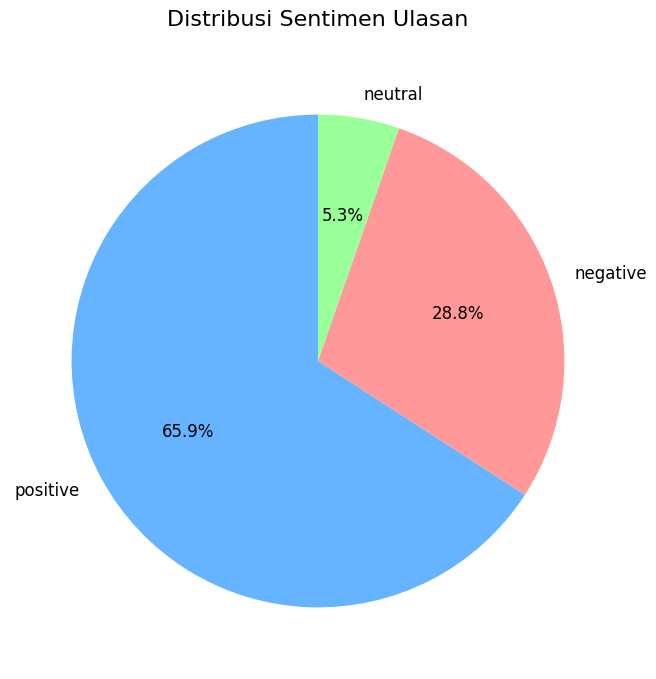

In [139]:
# Hitung jumlah data untuk setiap sentimen
sentiment_counts = clean_df['polarity'].value_counts()

# Buat pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff', '#ff9999', '#99ff99'],  # Warna biru, merah muda, hijau muda
    textprops={'fontsize': 12}
)

# Tambah judul
plt.title('Distribusi Sentimen Ulasan', fontsize=16, pad=20)

# Tampilkan pie chart
plt.show()

**Insight:** Dari informasi frekuensi tiap kategori review, diperoleh informasi bahwa review positif mendominasi yang menunjukkan bahwa aplikasi duolingo cukup baik dan diterima oleh pengguna.

In [140]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'positive_tweets' yang hanya berisi tweet dengan polaritas positif.
positive_tweets = clean_df[clean_df['polarity'] == 'positive']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'positive_tweets'.
positive_tweets = positive_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'positive_tweets' berdasarkan 'polarity_score' secara menurun.
positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False)

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
positive_tweets = positive_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
positive_tweets.index += 1

In [141]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'negative_tweets' yang hanya berisi tweet dengan polaritas negatif.
negative_tweets = clean_df[clean_df['polarity'] == 'negative']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'negative_tweets'.
negative_tweets = negative_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'negative_tweets' berdasarkan 'polarity_score' secara menaik (ascending).
negative_tweets = negative_tweets.sort_values(by='polarity_score', ascending=True)

# Memilih 10 baris pertama dari DataFrame yang sudah diurutkan.
negative_tweets = negative_tweets[0:10]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
negative_tweets = negative_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
negative_tweets.index += 1

In [142]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'neutral_tweets' yang hanya berisi tweet dengan polaritas negatif.
neutral_tweets = clean_df[clean_df['polarity'] == 'neutral']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'neutral_tweets'.
neutral_tweets = neutral_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'neutral_tweets' berdasarkan 'polarity_score' secara menaik (ascending).
neutral_tweets = neutral_tweets.sort_values(by='polarity_score', ascending=True)

# Memilih 10 baris pertama dari DataFrame yang sudah diurutkan.
neutral_tweets = neutral_tweets[0:10]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
neutral_tweets = neutral_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
neutral_tweets.index += 1

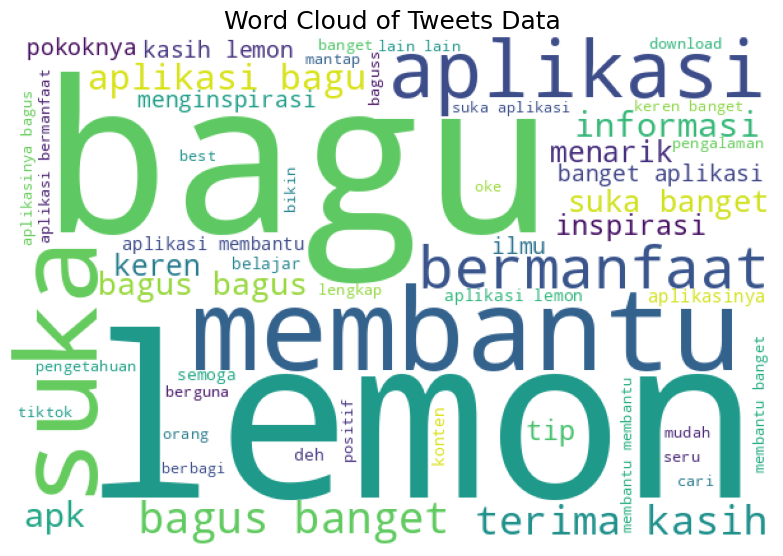

In [143]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'clean_df'.
for tweet in clean_df['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

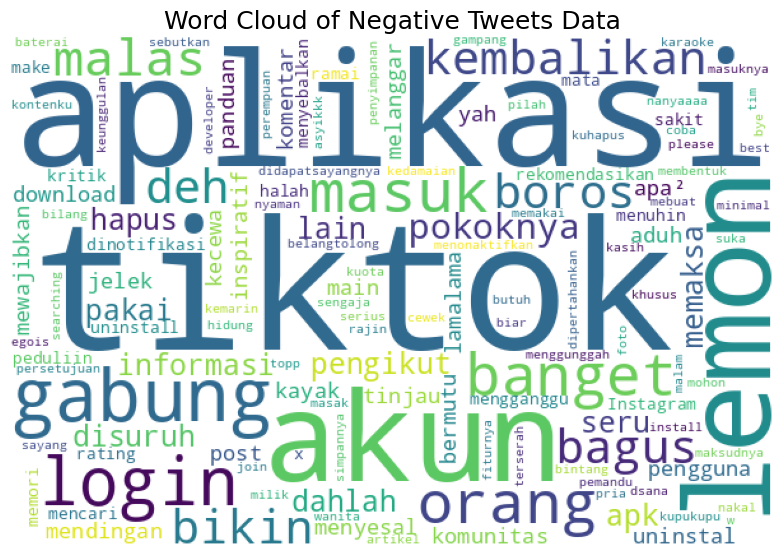

In [144]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet negatif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'negative_tweets'.
for tweet in negative_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

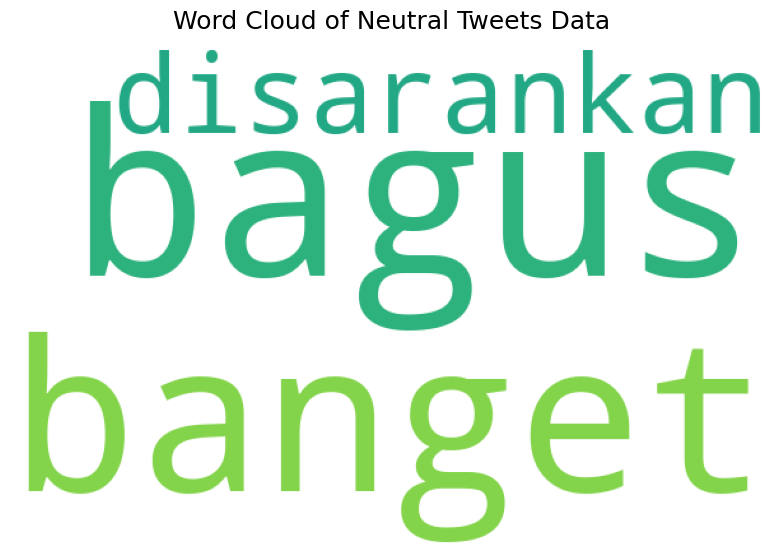

In [145]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet netral.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'neutral_tweets'.
for tweet in neutral_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Neutral Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

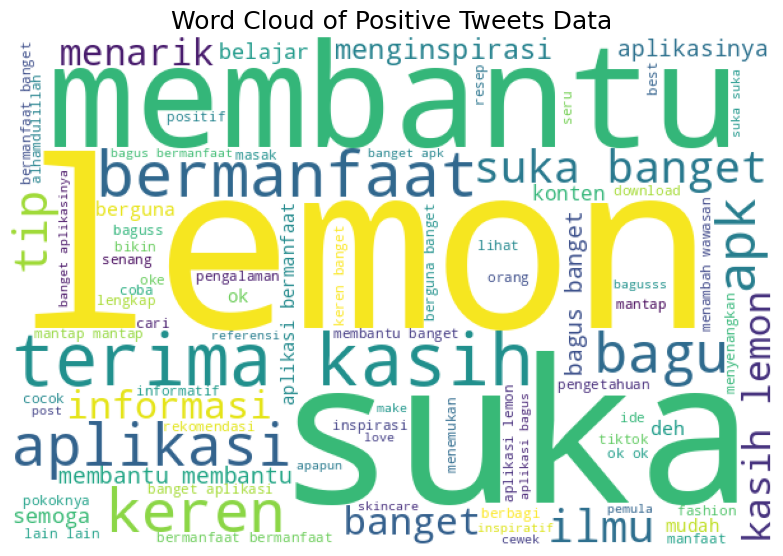

In [146]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet positif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'positive_tweets'.
for tweet in positive_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

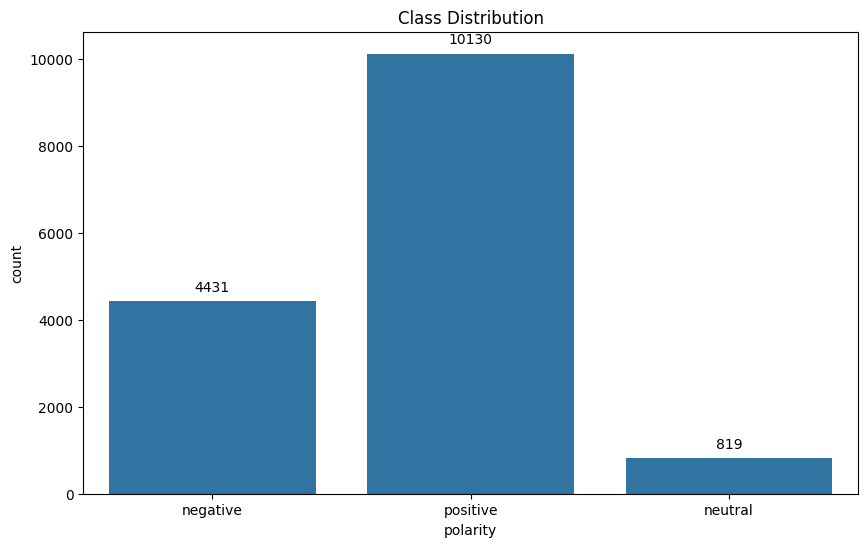

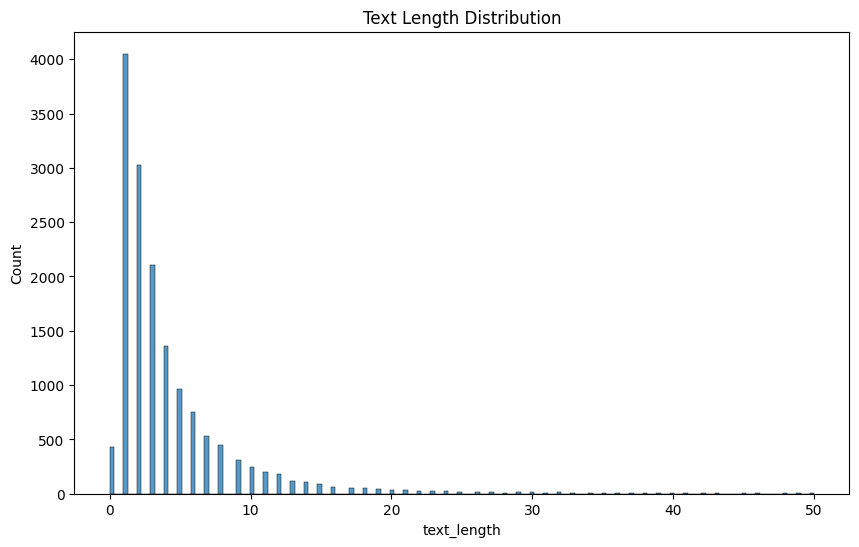

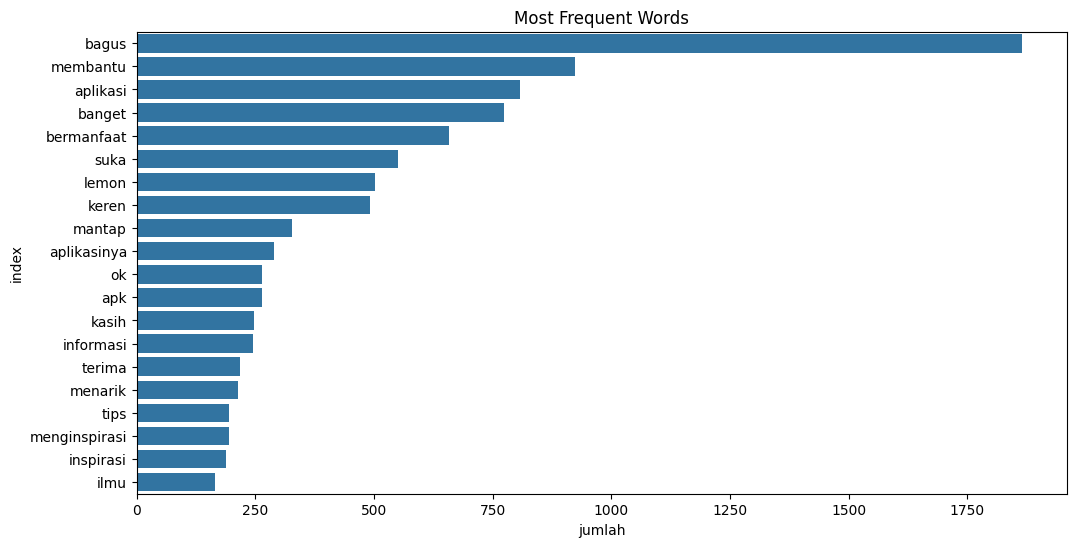

In [147]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Check class distribution
class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# Set the figure size
plt.figure(figsize=(10, 6))

# Visualize text length distribution
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

**Insight:** Berdasarkan analisis kata yang sering muncul dalam review aplikasi Duolingo, dapat diinterpretasikan bahwa pengguna umumnya memberikan tanggapan yang sangat positif terhadap aplikasi ini. Kata-kata seperti "bagus", "membantu", "bermanfaat", dan "keren" mendominasi ulasan, menunjukkan bahwa mayoritas pengguna merasa aplikasi ini memberikan pengalaman belajar bahasa yang efektif dan menyenangkan.

Beberapa kata kunci positif lain yang sering muncul antara lain "suka", "mantap", dan "menarik", yang mengindikasikan tingkat kepuasan pengguna yang tinggi. Kata "banget" (yang dalam bahasa informal berarti 'sekali' atau 'sangat') sering digunakan bersama kata sifat positif, memperkuat intensitas umpan balik positif tersebut.

Ditemukan juga kata-kata seperti "informasi", "tips", "menginspirasi", dan "ilmu" yang menunjukkan bahwa pengguna menghargai konten edukatif dalam aplikasi ini. Kata "aplikasi" dan "aplikasinya" yang sering muncul menguatkan bahwa review memang berfokus pada evaluasi terhadap aplikasi itu sendiri.

Secara keseluruhan, analisis frekuensi kata ini mengungkapkan sentimen yang sangat positif dari pengguna Duolingo, dengan penekanan pada manfaat pembelajaran, kualitas aplikasi, dan pengalaman pengguna yang memuaskan. Hal ini sesuai dengan reputasi Duolingo sebagai salah satu aplikasi belajar bahasa paling populer yang banyak direkomendasikan.

## **Data Splitting**

In [148]:
clean_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,text_length
0,4041b377-b5dd-4f58-8610-80f0502e5b8f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Aplikasi yang menarik, kita bisa berbagi cerita dan sharing banyak hal denga pengguna lainnya. Ada fitur editing yang mudah diaplikasikan, membantu sekali untuk kreator pemula. Sayangnya, postingan yang muncul seringkali postingan lama, bukan yang terbaru. Semoga segera update agar postingan baru muncul di beranda paling atas.",5,1111,7.9.5,2025-01-30 12:22:40,7.9.5,aplikasi yang menarik kita bisa berbagi cerita dan sharing banyak hal denga pengguna lainnya ada fitur editing yang mudah diaplikasikan membantu sekali untuk kreator pemula sayangnya postingan yang muncul seringkali postingan lama bukan yang terbaru semoga segera update agar postingan baru muncul di beranda paling atas,aplikasi yang menarik kita bisa berbagi cerita dan sharing banyak hal denga pengguna lainnya ada fitur editing yang mudah diaplikasikan membantu sekali untuk kreator pemula sayangnya postingan yang muncul seringkali postingan lama bukan yang terbaru semoga segera update agar postingan baru muncul di beranda paling atas,aplikasi yang menarik kita bisa berbagi cerita dan berbagi banyak hal denga pengguna lainnya ada fitur mengedit yang mudah diaplikasikan membantu sekali untuk kreator pemula sayangnya post yang muncul sering kali post lama bukan yang terbaru semoga segera update agar post baru muncul di beranda paling atas,"[aplikasi, yang, menarik, kita, bisa, berbagi, cerita, dan, berbagi, banyak, hal, denga, pengguna, lainnya, ada, fitur, mengedit, yang, mudah, diaplikasikan, membantu, sekali, untuk, kreator, pemula, sayangnya, post, yang, muncul, sering, kali, post, lama, bukan, yang, terbaru, semoga, segera, update, agar, post, baru, muncul, di, beranda, paling, atas]","[aplikasi, menarik, berbagi, cerita, berbagi, denga, pengguna, fitur, mengedit, mudah, diaplikasikan, membantu, kreator, pemula, sayangnya, post, muncul, kali, post, terbaru, semoga, update, post, muncul, beranda]",aplikasi menarik berbagi cerita berbagi denga pengguna fitur mengedit mudah diaplikasikan membantu kreator pemula sayangnya post muncul kali post terbaru semoga update post muncul beranda,-2,negative,25
1,3591ad33-9acb-45ef-90de-9d1a400d80ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"kasih 4dlu klo bagus kaya tiktok dan waveful nnti tak kasih bintang5 ,rada susah buat pertemanan sama fiturnya blm paham klo pemula ,klo di waveful kan simple pemula saja gampang buat nyari followers ,udah gitu dollar nya cepat monet",4,12,8.4.0,2025-03-30 11:36:49,8.4.0,kasih dlu klo bagus kaya tiktok dan waveful nnti tak kasih bintang rada susah buat pertemanan sama fiturnya blm paham klo pemula klo di waveful kan simple pemula saja gampang buat nyari followers udah gitu dollar nya cepat monet,kasih dlu klo bagus kaya tiktok dan waveful nnti tak kasih bintang rada susah buat pertemanan sama fiturnya blm paham klo pemula klo di waveful kan simple pemula saja gampang buat nyari followers udah gitu dollar nya cepat monet,kasih dulu kalau bagus kaya tiktok dan waveful nanti tidak kasih bintang rada susah buat pertemanan sama fiturnya belum paham kalau pemula kalau di waveful kan simple pemula saja gampang buat mencari pengikut sudah begitu dollar nya cepat monet,"[kasih, dulu, kalau, bagus, kaya, tiktok, dan, waveful, nanti, tidak, kasih, bintang, rada, susah, buat, pertemanan, sama, fiturnya, belum, paham, kalau, pemula, kalau, di, waveful, kan, simple, pemula, saja, gampang, buat, mencari, pengikut, sudah, begitu, dollar, nya, cepat, monet]","[kasih, bagus, kaya, tiktok, waveful, kasih, bintang, rada, susah,

In [149]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

# Pemodelan

In [189]:
# Fungsi untuk plot history training
def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')

    plt.tight_layout()
    plt.show()

# Early stopping untuk mencegah overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

## Skema 1: RNN dengan TF-IDF (80/20)

In [190]:
# Model RNN
def build_rnn_model():
    model = Sequential()
    model.add(SimpleRNN(128, input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]), activation='relu'))
    model.add(Dense(y_train.shape[1], activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    return model

In [191]:
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

# Praproses label
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

In [192]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_categorical, test_size=0.2, random_state=42)

# Ubah format input untuk RNN
X_train_rnn = X_train.toarray().reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_rnn = X_test.toarray().reshape(X_test.shape[0], 1, X_test.shape[1])

In [193]:
rnn_model = build_rnn_model()
rnn_history = rnn_model.fit(X_train_rnn, y_train,
                           epochs=100,
                           batch_size=32,
                           validation_data=(X_test_rnn, y_test),
                           callbacks=[early_stop],
                           verbose=1)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


385/385 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7361 - loss: 0.7142 - val_accuracy: 0.9051 - val_loss: 0.3108
Epoch 2/100
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9148 - loss: 0.2821 - val_accuracy: 0.9249 - val_loss: 0.2814
Epoch 3/100
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9283 - loss: 0.2475 - val_accuracy: 0.9265 - val_loss: 0.2770
Epoch 4/100
385/385 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9300 - loss: 0.2430 - val_accuracy: 0.9272 - val_loss: 0.2764
Epoch 5/100
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9279 - loss: 0.2389 - val_accuracy: 0.9301 - val_loss: 0.2766
Epoch 6/100
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9344 - loss: 0.2216 - val_accuracy: 0.9304 - val_loss: 0.2755
Epoch 7/100
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9365 - loss: 0.2146 - val_accuracy: 0.9288 - val_loss: 0.2773
Epoch 8/100
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9391 - loss: 0.2069 - val_accuracy: 0.9304


RNN with TF-IDF Results:
Training Loss: 0.2120 | Training Accuracy: 0.9375
Testing Loss: 0.2755 | Testing Accuracy: 0.9304


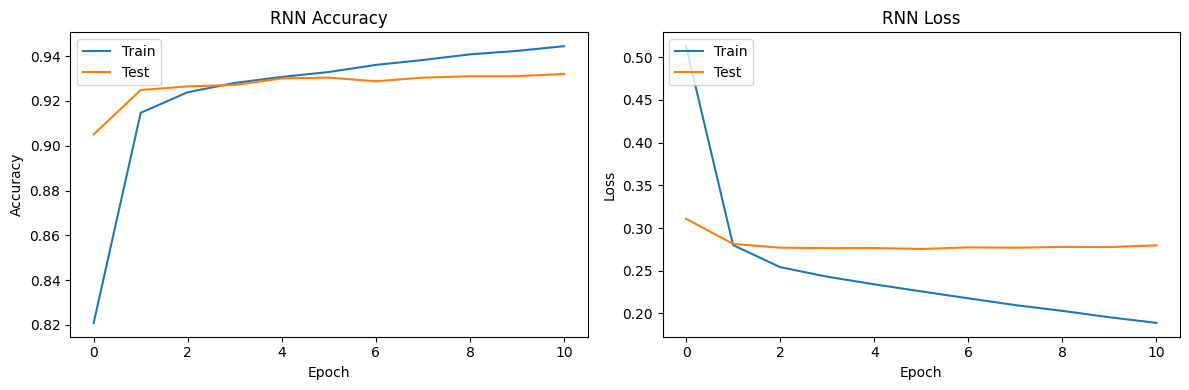

In [194]:
# Evaluasi RNN
rnn_train_loss, rnn_train_acc = rnn_model.evaluate(X_train_rnn, y_train, verbose=0)
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(X_test_rnn, y_test, verbose=0)

print("\nRNN with TF-IDF Results:")
print(f"Training Loss: {rnn_train_loss:.4f} | Training Accuracy: {rnn_train_acc:.4f}")
print(f"Testing Loss: {rnn_test_loss:.4f} | Testing Accuracy: {rnn_test_acc:.4f}")
plot_history(rnn_history, 'RNN')

**Insight:**

Berdasarkan grafik performa model RNN di atas, dapat dilihat bahwa model memiliki performa yang cukup baik, tetapi sedikit lebih rentan terhadap overfitting. Pada grafik akurasi di sebelah kiri, akurasi pelatihan meningkat secara konsisten hingga mencapai sekitar 94%. Sementara itu, akurasi pada data pengujian mengalami kenaikan cepat di awal dan kemudian cenderung stabil di kisaran 92–93%. Adanya sedikit jarak antara akurasi pelatihan dan pengujian menunjukkan bahwa model cenderung lebih belajar pada data training daripada mampu menggeneralisasi secara sempurna ke data baru.

Hal ini juga terlihat pada grafik loss di sebelah kanan, di mana nilai loss pada data pelatihan terus menurun secara konsisten, sementara loss pada data pengujian hanya menurun di awal lalu stagnan dan sedikit fluktuatif. Perbedaan yang mulai terlihat antara loss pelatihan dan pengujian menunjukkan tanda-tanda awal overfitting.

Secara keseluruhan, model RNN menunjukkan kinerja yang kuat, dengan akurasi tinggi dan stabil, namun memerlukan perhatian khusus terhadap potensi overfitting jika dilatih dalam waktu yang lebih lama atau dengan dataset yang lebih kompleks

## Skema 2: LSTM dengan TF-IDF (70/30)

In [195]:
# Model LSTM
def build_lstm_model():
    model = Sequential()
    model.add(LSTM(128, input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]), activation='relu'))
    model.add(Dense(y_train.shape[1], activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    return model

In [196]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_categorical, test_size=0.3, random_state=42)

# Ubah format input untuk LSTM
X_train_lstm = X_train.toarray().reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.toarray().reshape(X_test.shape[0], 1, X_test.shape[1])

In [197]:
lstm_model = build_lstm_model()
lstm_history = lstm_model.fit(X_train_lstm, y_train,
                             epochs=100,
                             batch_size=32,
                             validation_data=(X_test_lstm, y_test),
                             callbacks=[early_stop],
                             verbose=1)

Epoch 1/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7139 - loss: 0.8436 - val_accuracy: 0.8823 - val_loss: 0.3629
Epoch 2/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8985 - loss: 0.3159 - val_accuracy: 0.9174 - val_loss: 0.2920
Epoch 3/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9186 - loss: 0.2691 - val_accuracy: 0.9209 - val_loss: 0.2836
Epoch 4/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9260 - loss: 0.2535 - val_accuracy: 0.9250 - val_loss: 0.2811
Epoch 5/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9259 - loss: 0.2428 - val_accuracy: 0.9241 - val_loss: 0.2794
Epoch 6/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9303 - loss: 0.2365 - val_accuracy: 0.9239 - val_loss: 0.2803
Epoch 7/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9279 - loss: 0.2345 - val_accuracy: 0.9235 - val_loss: 0.2795
Epoch 8/100
337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9316 - loss: 0.2321 - val_acc


LSTM with TF-IDF Results:
Training Loss: 0.2119 | Training Accuracy: 0.9366
Testing Loss: 0.2782 | Testing Accuracy: 0.9272


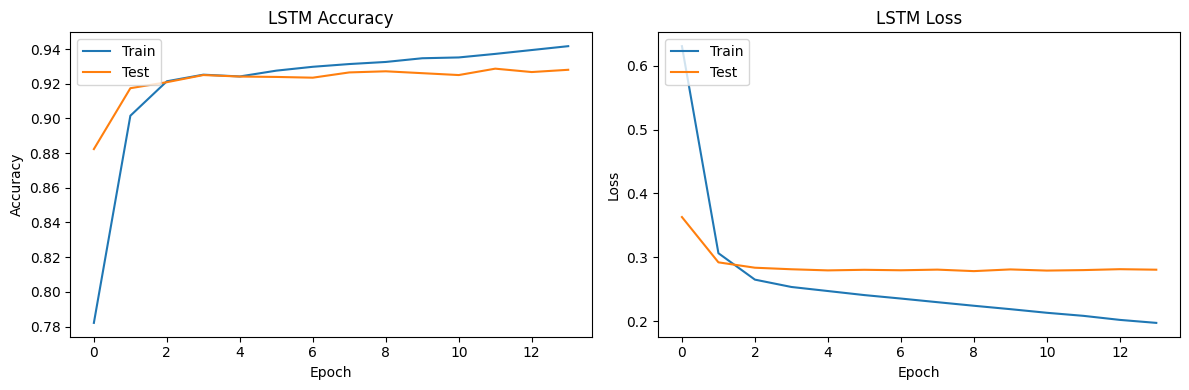

In [199]:
# Evaluasi LSTM
lstm_train_loss, lstm_train_acc = lstm_model.evaluate(X_train_lstm, y_train, verbose=0)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test_lstm, y_test, verbose=0)

print("\nLSTM with TF-IDF Results:")
print(f"Training Loss: {lstm_train_loss:.4f} | Training Accuracy: {lstm_train_acc:.4f}")
print(f"Testing Loss: {lstm_test_loss:.4f} | Testing Accuracy: {lstm_test_acc:.4f}")
plot_history(lstm_history, 'LSTM')

**Insight:**

Berdasarkan grafik hasil pelatihan model LSTM dengan representasi TF-IDF, dapat disimpulkan bahwa model menunjukkan performa yang sangat baik secara keseluruhan. Pada grafik kiri (akurasi), terlihat bahwa akurasi data pelatihan meningkat tajam sejak awal epoch dan mencapai sekitar 94% di akhir pelatihan. Akurasi pada data pengujian juga menunjukkan pola serupa, naik dengan cepat dan kemudian stabil di kisaran 92–93%, yang menunjukkan bahwa model tidak mengalami overfitting secara signifikan.

Sementara itu, grafik kanan (loss) menunjukkan penurunan nilai loss yang konsisten pada data pelatihan, menandakan bahwa model terus belajar dan meminimalkan kesalahan prediksi. Loss pada data pengujian juga turun tajam di awal dan kemudian stabil, meskipun tidak serendah loss pada data pelatihan. Perbedaan ini cukup wajar dan menunjukkan bahwa model mampu melakukan generalisasi dengan baik untuk data baru.

Secara keseluruhan, kombinasi dari akurasi yang tinggi dan stabil dengan nilai loss yang rendah menunjukkan bahwa model LSTM dengan representasi TF-IDF memiliki kinerja yang solid dan layak digunakan.

## Skema 3: LSTM dengan BoW (80/20)

In [200]:
# Ekstraksi Fitur BoW
vectorizer = CountVectorizer(max_features=5000)  # Batasi vocabulary size
X_bow = vectorizer.fit_transform(X).toarray()

# Fitur BoW sebagai timestep
X_reshaped = X_bow.reshape(X_bow.shape[0], 1, X_bow.shape[1])

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_categorical, test_size=0.2, random_state=42)

In [202]:
# Bangun Model LSTM
lstm_BoW_model = Sequential()
lstm_BoW_model.add(LSTM(128, input_shape=(1, X_train.shape[2])))  # input_shape = (timesteps, features)
lstm_BoW_model.add(Dense(y_train.shape[1], activation='softmax'))
lstm_BoW_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [204]:
# Training
lstm_BoW_history = lstm_BoW_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.9445 - loss: 0.1802 - val_accuracy: 0.9386 - val_loss: 0.2386
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9711 - loss: 0.1098 - val_accuracy: 0.9457 - val_loss: 0.2453
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9806 - loss: 0.0714 - val_accuracy: 0.9470 - val_loss: 0.2527
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9870 - loss: 0.0496 - val_accuracy: 0.9516 - val_loss: 0.2750
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9925 - loss: 0.0347 - val_accuracy: 0.9493 - val_loss: 0.2933
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.9933 - loss: 0.0302 - val_accuracy: 0.9522 - val_loss: 0.3126
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9954 - loss: 0.0221 - val_accuracy: 0.9542 - val_loss: 0.3343
Epoch 8/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.9971 - loss: 0.0174 - 


LSTM with BoW Results:
Training Accuracy: 0.9995 | Training Loss: 0.0029
Testing Accuracy: 0.9519 | Testing Loss: 0.6186


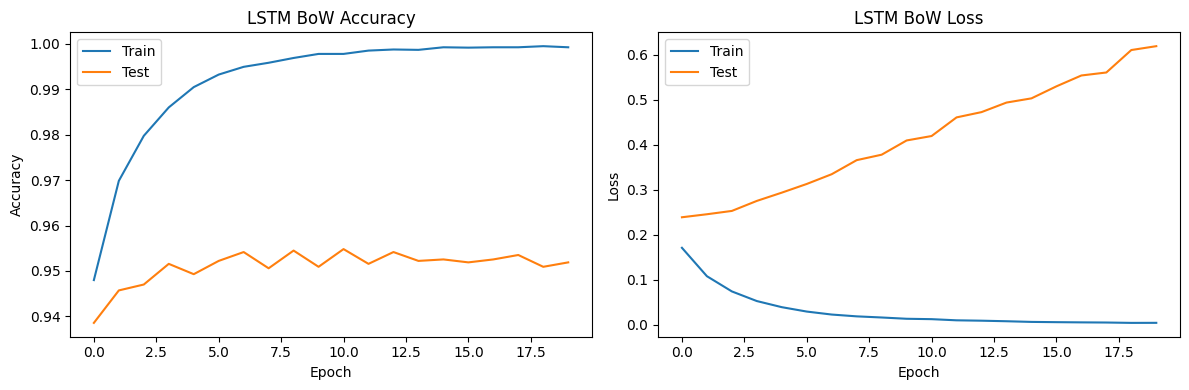

In [205]:
# Evaluasi
lstm_BoW_train_loss, lstm_BoW_train_acc = lstm_BoW_model.evaluate(X_train, y_train, verbose=0)
lstm_BoW_test_loss, lstm_BoW_test_acc = lstm_BoW_model.evaluate(X_test, y_test, verbose=0)

print("\nLSTM with BoW Results:")
print(f"Training Accuracy: {lstm_BoW_train_acc:.4f} | Training Loss: {lstm_BoW_train_loss:.4f}")
print(f"Testing Accuracy: {lstm_BoW_test_acc:.4f} | Testing Loss: {lstm_BoW_test_loss:.4f}")

plot_history(lstm_BoW_history, 'LSTM BoW')

**Insight:**

Berdasarkan grafik performa model LSTM dengan representasi Bag of Words (BoW), terlihat bahwa model menunjukkan performa sangat baik pada data pelatihan namun tidak sebanding pada data pengujian, yang mengindikasikan adanya overfitting. Akurasi pelatihan meningkat secara signifikan hingga mencapai hampir 100% (0.9995), disertai dengan penurunan nilai loss pelatihan hingga sangat rendah (0.0029). Sebaliknya, meskipun akurasi pengujian cukup tinggi yaitu sekitar 95.19%, tetapi tidak mengalami peningkatan berarti seiring waktu, dan bahkan menunjukkan fluktuasi kecil. Selain itu, nilai loss pada data pengujian justru terus meningkat dari awal hingga akhir pelatihan dan mencapai angka 0.6186 di akhir epoch.

Pola ini menunjukkan bahwa model terlalu fokus pada pola-pola dalam data pelatihan dan tidak mampu beradaptasi dengan baik terhadap data baru. Dengan kata lain, meskipun model sangat akurat dalam mengenali data yang sudah dilihat sebelumnya, kemampuannya untuk melakukan generalisasi terhadap data yang belum pernah dilihat masih kurang optimal.

# Evaluasi Model

In [206]:
# Membuat DataFrame untuk hasil akurasi
results_df = pd.DataFrame({
    'Model': ['RNN TF-IDF (80/20)', 'LSTM TF-IDF (70/30)', 'LSTM BoW (80/20)'],
    'Accuracy Train': [rnn_train_acc, lstm_train_acc, lstm_BoW_train_acc],
    'Accuracy Test': [rnn_test_acc, lstm_test_acc, lstm_BoW_test_acc]
})
# Menampilkan  kolom "Accuracy"
accuracy = results_df[['Model', 'Accuracy Train', 'Accuracy Test']]
print(accuracy)

                 Model  Accuracy Train  Accuracy Test
0   RNN TF-IDF (80/20)        0.937500       0.930429
1  LSTM TF-IDF (70/30)        0.936560       0.927178
2     LSTM BoW (80/20)        0.999512       0.951886


## **Hasi Analisis**

### RNN TF-IDF (80/20):
> Model RNN dengan ekstraksi fitur TF-IDF dan pembagian data 80/20 menunjukkan performa yang sangat baik, dengan akurasi training sebesar **93.75%** dan akurasi testing **93.04%**. Konsistensi antara akurasi training dan testing yang hampir sama mengindikasikan model ini tidak mengalami overfitting. Hasil ini membuktikan bahwa arsitektur RNN sederhana dengan TF-IDF mampu menangkap pola sequential secara efektif untuk analisis sentimen.

...

### LSTM TF-IDF (70/30):
> Model LSTM dengan TF-IDF dan pembagian data 70/30 mencapai akurasi training **93.66%** dan testing **92.72%**. Performa yang stabil ini menunjukkan keunggulan LSTM dalam memproses dependensi jarak jauh tanpa overfitting.

...

### LSTM BoW (80/20):
> Model LSTM dengan ekstraksi fitur Bag-of-Words (BoW) menunjukkan akurasi training nyaris sempurna (**99.95%**), tetapi mengalami penurunan akurasi testing menjadi **95.19%** yang mengindikasikan adanya sedikit overfitting.

---
---

### **Kesimpulan:**

Hasil analisis menunjukkan bahwa model RNN dan LSTM dengan ekstraksi fitur TF-IDF sama-sama menawarkan stabilitas yang tinggi menjadikan kedua model tersebut sangat cocok untuk implementasi pada analisis yang mengutamakan konsistensi performa dan generalisasi yang baik. Sementara itu, pendekatan LSTM dengan BoW menunjukkan akurasi training sangat tinggi yang mengindikasikan adanya kecenderungan overfitting. Artinya, model ini mungkin terlalu spesifik mempelajari pola-pola unik pada data training sehingga kurang optimal ketika dihadapkan pada data baru. Berdasarkan pertimbangan ini, untuk implementasi nyata yang memerlukan keseimbangan antara akurasi dan kemampuan generalisasi, **RNN dengan TF-IDF** merupakan pilihan yang lebih unggul. Model ini tidak hanya menunjukkan performa yang stabil, tetapi juga lebih dapat diandalkan untuk memproses data baru yang belum pernah dilihat sebelumnya.

# Inference

In [207]:
def predict_sentiment(text, model_choice='rnn_tfidf'):
    """
    Predict sentiment for input text using specified deep learning model

    Parameters:
    text (str): Input text to analyze
    model_choice (str): Model to use. Options:
        - 'rnn_tfidf': RNN with TF-IDF
        - 'lstm_tfidf': LSTM with TF-IDF
        - 'lstm_bow': LSTM with Bag-of-Words

    Returns:
    str: Predicted sentiment ('positive', 'negative', or 'neutral')
    """
    # Preprocessing pipeline
    text_cleaned = cleaningText(text)
    text_casefolded = casefoldingText(text_cleaned)
    text_slangfixed = fix_slangwords(text_casefolded)
    text_tokenized = tokenizingText(text_slangfixed)
    text_filtered = filteringText(text_tokenized)
    text_final = toSentence(text_filtered)

    # Model prediction
    if model_choice == 'rnn_tfidf':
        # Transform text to TF-IDF
        X_text = tfidf.transform([text_final]).toarray()
        # Reshape for RNN (samples, timesteps, features)
        X_text_reshaped = X_text.reshape(1, 1, X_text.shape[1])
        pred = rnn_model.predict(X_text_reshaped)

    elif model_choice == 'lstm_tfidf':
        # Transform text to TF-IDF
        X_text = tfidf.transform([text_final]).toarray()
        # Reshape for LSTM (samples, timesteps, features)
        X_text_reshaped = X_text.reshape(1, 1, X_text.shape[1])
        pred = lstm_model.predict(X_text_reshaped)

    elif model_choice == 'lstm_bow':
        # Transform text to BoW
        X_text = vectorizer.transform([text_final]).toarray()
        # Reshape for LSTM (samples, timesteps, features)
        X_text_reshaped = X_text.reshape(1, 1, X_text.shape[1])
        pred = lstm_BoW_model.predict(X_text_reshaped)

    else:
        raise ValueError(f"Unknown model choice: {model_choice}")

    # Convert prediction to sentiment label
    predicted_class = np.argmax(pred, axis=1)
    sentiment_labels = ['negative', 'neutral', 'positive']  # Sesuaikan dengan label Anda
    return sentiment_labels[predicted_class[0]]

# Example usage with all model types
test_phrases = [
    "Aplikasi ini sangat membantu untuk belajar",
    "Saya menyesal menginstall aplikasi ini",
    "Lumayan sih..."
]

model_choices = {
    'RNN with TF-IDF': 'rnn_tfidf',
    'LSTM with TF-IDF': 'lstm_tfidf',
    'LSTM with BoW': 'lstm_bow'
}

for model_name, model_code in model_choices.items():
    print(f"\n=== Predictions using {model_name} ===")
    for phrase in test_phrases:
        sentiment = predict_sentiment(phrase, model_choice=model_code)
        print(f"Text: '{phrase[:30]}...'")
        print(f"Predicted sentiment: {sentiment}")
    print("="*50)


=== Predictions using RNN with TF-IDF ===


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
Text: 'Aplikasi ini sangat membantu u...'
Predicted sentiment: positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Text: 'Saya menyesal menginstall apli...'
Predicted sentiment: negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Text: 'Lumayan sih......'
Predicted sentiment: neutral

=== Predictions using LSTM with TF-IDF ===


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step
Text: 'Aplikasi ini sangat membantu u...'
Predicted sentiment: positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Text: 'Saya menyesal menginstall apli...'
Predicted sentiment: negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Text: 'Lumayan sih......'
Predicted sentiment: neutral

=== Predictions using LSTM with BoW ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
Text: 'Aplikasi ini sangat membantu u...'
Predicted sentiment: neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Text: 'Saya menyesal menginstall apli...'
Predicted sentiment: negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Text: 'Lumayan sih......'
Predicted sentiment: neutral
